C:\Users\Eef\AppData\Local\Temp\ipykernel_21856\2483010821.py:20: RuntimeWarning: Mean of empty slice
  age_err = np.nanmean(np.vstack([np.abs(err_plus), np.abs(err_minus)]), axis=0)


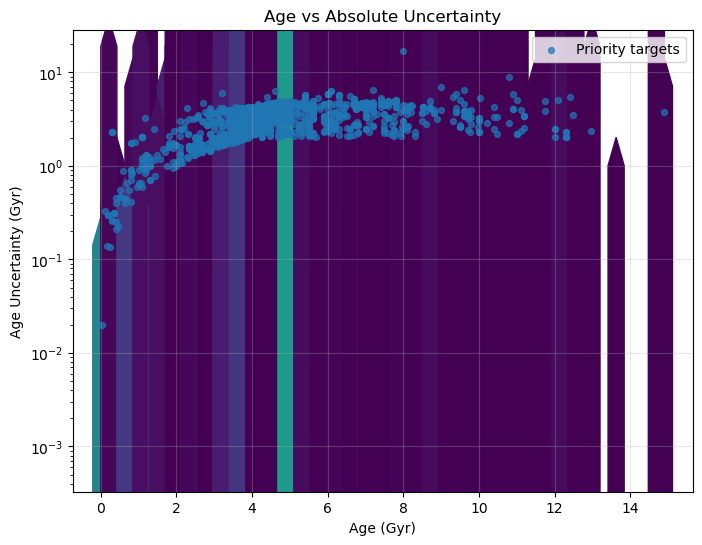

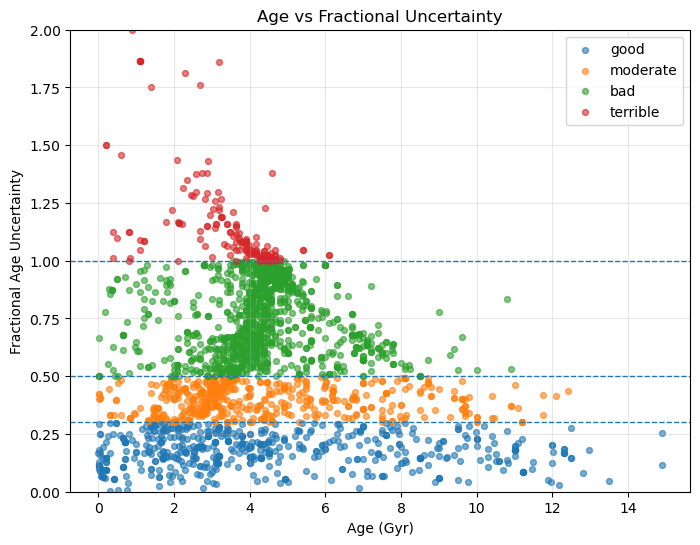


TOP PRIORITY TARGETS FOR FRIENDFINDER:

      hostname  age  age_err  frac_err age_quality
      WASP-136  NaN      NaN       NaN      no_age
        KELT-1  NaN      NaN       NaN      no_age
       WASP-44  NaN      NaN       NaN      no_age
       WASP-32  NaN      NaN       NaN      no_age
       WASP-26  NaN      NaN       NaN      no_age
       TOI-260  NaN      NaN       NaN      no_age
       WASP-20  NaN      NaN       NaN      no_age
       WASP-45  NaN      NaN       NaN      no_age
      WASP-190  NaN      NaN       NaN      no_age
      TOI-2406  NaN      NaN       NaN      no_age
      HAT-P-16  NaN      NaN       NaN      no_age
        K2-149  NaN      NaN       NaN      no_age
        K2-206  NaN      NaN       NaN      no_age
        K2-217  NaN      NaN       NaN      no_age
        K2-216  NaN      NaN       NaN      no_age
        K2-207  NaN      NaN       NaN      no_age
        K2-385  NaN      NaN       NaN      no_age
        K2-220  NaN      NaN       NaN   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# Load and clean
# -----------------------
df = pd.read_csv("Targets.csv")

name_col = "hostname"  # change if needed

for col in ["st_age", "st_ageerr1", "st_ageerr2"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

age = df["st_age"]
err_plus = df["st_ageerr1"]
err_minus = df["st_ageerr2"]

# symmetric absolute error estimate
age_err = np.nanmean(np.vstack([np.abs(err_plus), np.abs(err_minus)]), axis=0)
frac_err = age_err / age

df["age"] = age
df["age_err"] = age_err
df["frac_err"] = frac_err

# -----------------------
# Categorize
# -----------------------
df["age_quality"] = "unknown"

valid_age = np.isfinite(df["age"]) & (df["age"] > 0)
valid_err = np.isfinite(df["age_err"])
valid_frac = np.isfinite(df["frac_err"])

mask = valid_age & valid_err & valid_frac

df.loc[mask & (df["frac_err"] < 0.3), "age_quality"] = "good"
df.loc[mask & (df["frac_err"] >= 0.3) & (df["frac_err"] < 0.5), "age_quality"] = "moderate"
df.loc[mask & (df["frac_err"] >= 0.5) & (df["frac_err"] < 1.0), "age_quality"] = "bad"
df.loc[mask & (df["frac_err"] >= 1.0), "age_quality"] = "terrible"
df.loc[~valid_age, "age_quality"] = "no_age"

# priority flag for FriendFinder follow-up
df["priority_for_friendfinder"] = (
    (~valid_age) |
    ((df["age_err"] > 2.0) & valid_err) |
    ((df["frac_err"] > 0.5) & valid_frac)
)

# -----------------------
# Plot 1: hexbin + bad overlays
# -----------------------
plot_mask = mask

plt.figure(figsize=(8, 6))
plt.hexbin(
    df.loc[plot_mask, "age"],
    df.loc[plot_mask, "age_err"],
    gridsize=35,
    mincnt=1
)

bad_mask = plot_mask & df["priority_for_friendfinder"]
plt.scatter(
    df.loc[bad_mask, "age"],
    df.loc[bad_mask, "age_err"],
    s=18,
    alpha=0.7,
    label="Priority targets"
)

plt.xlabel("Age (Gyr)")
plt.ylabel("Age Uncertainty (Gyr)")
plt.title("Age vs Absolute Uncertainty")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------
# Plot 2: categorized scatter
# -----------------------
plt.figure(figsize=(8, 6))

for quality in ["good", "moderate", "bad", "terrible"]:
    qmask = plot_mask & (df["age_quality"] == quality)
    plt.scatter(
        df.loc[qmask, "age"],
        df.loc[qmask, "frac_err"],
        s=18,
        alpha=0.6,
        label=quality
    )

plt.axhline(0.3, linestyle="--", linewidth=1)
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)

plt.xlabel("Age (Gyr)")
plt.ylabel("Fractional Age Uncertainty")
plt.title("Age vs Fractional Uncertainty")
plt.ylim(0, 2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------
# Sorted priority table
# -----------------------
priority_df = df[df["priority_for_friendfinder"]].copy()

sort_cols = []
ascending = []

# no-age first
priority_df["no_age_flag"] = ~np.isfinite(priority_df["age"])
sort_cols.append("no_age_flag")
ascending.append(False)

# then highest fractional error
sort_cols.append("frac_err")
ascending.append(False)

# then highest absolute error
sort_cols.append("age_err")
ascending.append(False)

priority_df = priority_df.sort_values(sort_cols, ascending=ascending)

cols_to_show = [c for c in [name_col, "age", "age_err", "frac_err", "age_quality"] if c in priority_df.columns]

print("\nTOP PRIORITY TARGETS FOR FRIENDFINDER:\n")
print(priority_df[cols_to_show].head(50).to_string(index=False))

In [2]:
import pandas as pd
import numpy as np

# -------------------------
# Load data
# -------------------------
targets = pd.read_csv("Targets.csv")
summary = pd.read_csv("FRIENDS/friends_density_summary.csv")

# -------------------------
# Clean names (IMPORTANT)
# -------------------------
def normalize(x):
    return str(x).strip().lower().replace("_", " ")

targets["_norm"] = targets["hostname"].map(normalize)
summary["_norm"] = summary["target"].map(normalize)

# -------------------------
# Merge datasets
# -------------------------
df = pd.merge(
    summary,
    targets[["_norm", "st_age", "st_ageerr1", "st_ageerr2"]],
    on="_norm",
    how="left"
)

# -------------------------
# Compute age metrics
# -------------------------
df["age"] = pd.to_numeric(df["st_age"], errors="coerce")

err_plus = pd.to_numeric(df["st_ageerr1"], errors="coerce")
err_minus = pd.to_numeric(df["st_ageerr2"], errors="coerce")

df["age_err"] = np.nanmean(
    np.vstack([np.abs(err_plus), np.abs(err_minus)]),
    axis=0
)

df["frac_err"] = df["age_err"] / df["age"]

# -------------------------
# Define priority flags
# -------------------------
df["no_age"] = ~np.isfinite(df["age"])
df["bad_age"] = df["frac_err"] > 0.5
df["terrible_age"] = df["frac_err"] > 1.0

df["priority"] = (
    df["no_age"] |
    df["bad_age"] |
    (df["age_err"] > 2)
)

# -------------------------
# Filter to only ones you have run
# (already true since summary is your run list)
# -------------------------
priority_df = df[df["priority"]].copy()

# -------------------------
# Sort intelligently
# -------------------------
priority_df = priority_df.sort_values(
    by=[
        "no_age",          # no age first
        "frac_err",        # then worst fractional error
        "adjusted_score",  # then strongest detection
    ],
    ascending=[False, False, False]
)

# -------------------------
# Output
# -------------------------
cols = [
    "target",
    "age",
    "age_err",
    "frac_err",
    "raw_score",
    "adjusted_score",
    "no_age",
]

print("\n=== PRIORITY TARGETS (already run through FriendFinder) ===\n")
print(priority_df[cols].head(30).to_string(index=False))

# Optional: save to CSV
priority_df.to_csv("priority_targets.csv", index=False)


=== PRIORITY TARGETS (already run through FriendFinder) ===

  target  age  age_err  frac_err  raw_score  adjusted_score  no_age
  K2-101  NaN      NaN       NaN   0.974262        0.961681    True
  K2-104  NaN      NaN       NaN   0.972830        0.960605    True
   K2-95  NaN      NaN       NaN   0.969764        0.957815    True
  K2-264  NaN      NaN       NaN   0.969542        0.957142    True
  K2-264  NaN      NaN       NaN   0.969542        0.957142    True
  K2-264  NaN      NaN       NaN   0.969542        0.957142    True
  K2-264  NaN      NaN       NaN   0.969542        0.957142    True
   K2-91  NaN      NaN       NaN   0.726810        0.663234    True
WASP-107  NaN      NaN       NaN   0.712514        0.654282    True
  K2-151  NaN      NaN       NaN   0.736423        0.642076    True
  K2-122  NaN      NaN       NaN   0.660613        0.617736    True
TOI-1696  NaN      NaN       NaN   0.686270        0.617382    True
TOI-1799  NaN      NaN       NaN   0.671668        0.5

C:\Users\Eef\AppData\Local\Temp\ipykernel_21856\1673905742.py:37: RuntimeWarning: Mean of empty slice
  df["age_err"] = np.nanmean(
